In [1]:
!pip install hitran-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
import time, os
import hapi

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [3]:
# ── Spectral range ────────────────────────────────────────────
LAMBDA_CENTER_NM = 763.84251         # O2 A-band peak (nm)
SCAN_HALF_NM     = 5.0              # ±5.0 nm (expanded for entire spectrum)

lambda_min_nm = LAMBDA_CENTER_NM - SCAN_HALF_NM
lambda_max_nm = LAMBDA_CENTER_NM + SCAN_HALF_NM

nu_min = 1e7 / lambda_max_nm
nu_max = 1e7 / lambda_min_nm

# NU_STEP is now calculated dynamically in the next cell

print(f'Wavelength range : {lambda_min_nm:.4f} – {lambda_max_nm:.4f} nm')
print(f'Wavenumber range : {nu_min:.4f} – {nu_max:.4f} cm⁻¹')

HAPI_DIR = './hapi_data'
os.makedirs(HAPI_DIR, exist_ok=True)
hapi.db_begin(HAPI_DIR)

print('\nDownloading O2 line data from HITRAN...')
# Fetch data for a wider range to capture more of the spectrum
hapi.fetch('O2_Aband', 7, 1, nu_min - 10.0, nu_max + 10.0) # Expanded buffer for wider range
print('Download complete ✓')

Wavelength range : 758.8425 – 768.8425 nm
Wavenumber range : 13006.5649 – 13177.9650 cm⁻¹
Using ./hapi_data



Data is fetched from http://hitran.org

BEGIN DOWNLOAD: O2_Aband
  65536 bytes written to ./hapi_data/O2_Aband.data
Header written to ./hapi_data/O2_Aband.header
END DOWNLOAD
                     Lines parsed: 133
PROCESSED
Download complete ✓


In [4]:
# ── Gas conditions ────────────────────────────────────────────
T_GAS  = 296.0
P_ATM  = 1.0
X_O2   = 0.21

N_POINTS = 50000
nu_grid  = np.linspace(nu_min, nu_max, N_POINTS)

# Dynamically calculate NU_STEP based on the new range and desired number of points
NU_STEP_CALC = (nu_max - nu_min) / (N_POINTS - 1)

nu_out, alpha_cm = hapi.absorptionCoefficient_Voigt(
    SourceTables  = 'O2_Aband',
    Diluent       = {'air': 1.0},
    Environment   = {'p': P_ATM, 'T': T_GAS},
    HITRAN_units  = False,
    WavenumberRange = [nu_min, nu_max],
    WavenumberStep  = NU_STEP_CALC, # Use the dynamically calculated step
    WavenumberWing  = 50,
)

alpha_nu_mm = np.array(alpha_cm) * 0.1   # cm⁻¹ → mm⁻¹
alpha_nu_mm=alpha_nu_mm*X_O2

# Convert wavenumber axis back to wavelength (nm)
nu_arr       = np.array(nu_out)
lambda_nm   = 1e7 / nu_arr
sort_idx    = np.argsort(lambda_nm)
lambda_nm   = lambda_nm[sort_idx]
alpha_nu_mm = alpha_nu_mm[sort_idx]

alpha_interp = interp1d(lambda_nm, alpha_nu_mm,
                        kind='linear', fill_value=0, bounds_error=False)

print(f'Peak absorption  : {alpha_nu_mm.max():.5f} mm⁻¹')
print(f'Peak wavelength  : {lambda_nm[np.argmax(alpha_nu_mm)]:.5f} nm')

{'air': 1.0}
0.439594 seconds elapsed for abscoef; nlines = 133
Peak absorption  : 0.00003 mm⁻¹
Peak wavelength  : 760.65444 nm


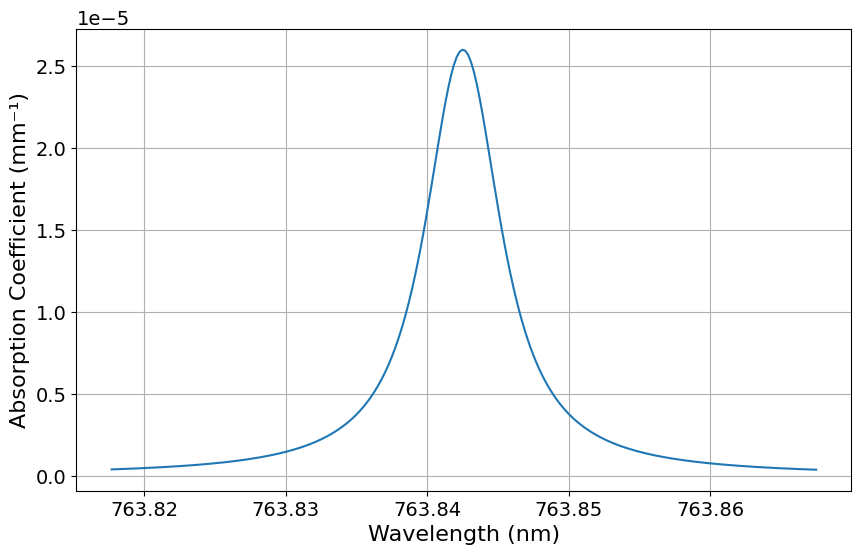

In [7]:
peak_center = 763.84251
peak_half_range = 0.025

lambda_min_plot = peak_center - peak_half_range
lambda_max_plot = peak_center + peak_half_range

# Filter the data for the desired peak range
mask = (lambda_nm >= lambda_min_plot) & (lambda_nm <= lambda_max_plot)
lambda_peak = lambda_nm[mask]
alpha_peak = alpha_nu_mm[mask]

plt.figure(figsize=(10, 6))
plt.plot(lambda_peak, alpha_peak) # Convert mm⁻¹ to m⁻¹
plt.xlabel('Wavelength (nm)', fontsize=16)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=16)
#plt.title(f'O2 A-Band Absorption Peak ({peak_center:.3f} nm)')
plt.grid(True)
plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Remove offset from x-axis
plt.tick_params(axis='both', labelsize=14) # Increased labelsize from 10 to 14
plt.gca().yaxis.get_offset_text().set_fontsize(14) # Increase font size of y-axis offset text
plt.show()

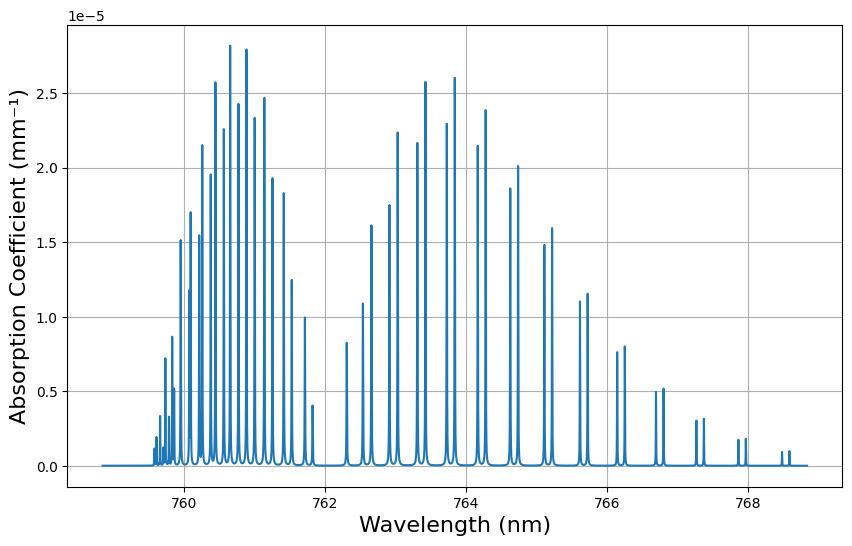

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(lambda_nm, alpha_nu_mm)  # Convert mm⁻¹ to m⁻¹ for better scale if needed, or keep as is
#plt.axvline(x=peak_center, color='r', linestyle='--', label='Peak Center')
plt.xlabel('Wavelength (nm)', fontsize=16)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=16)
#plt.title('Full O2 A-Band Absorption Spectrum')
plt.grid(True)
plt.tick_params(axis='both', labelsize=10)
plt.show()

In [ ]:
# ── Gas conditions for Water Vapor ────────────────────────────────────────────
T_GAS  = 296.0 # Gas temperature in K
P_ATM  = 1.0   # Total pressure in atm
X_H2O  = 0.01  # Mole fraction of water vapor, adjust as needed (e.g., 0.01 for 1%)

# Define H2O-specific spectral range. A strong H2O absorption band is around 1850 nm (near-infrared).
LAMBDA_CENTER_H2O_NM = 800.0
SCAN_HALF_H2O_NM     = 200.0 # Wider scan to capture multiple H2O lines

lambda_min_nm_H2O = LAMBDA_CENTER_H2O_NM - SCAN_HALF_H2O_NM
lambda_max_nm_H2O = LAMBDA_CENTER_H2O_NM + SCAN_HALF_H2O_NM

nu_min_H2O = 1e7 / lambda_max_nm_H2O
nu_max_H2O = 1e7 / lambda_min_nm_H2O

print(f'Wavelength range (H2O) : {lambda_min_nm_H2O:.4f} – {lambda_max_nm_H2O:.4f} nm')
print(f'Wavenumber range (H2O) : {nu_min_H2O:.4f} – {nu_max_H2O:.4f} cm⁻¹')

# Ensure H2O data is fetched from HITRAN.
# Molecule ID for H2O is 1, isotopologue 1 (H2_16O).
# A buffer of 50 cm⁻¹ is added to the wavenumber range for fetching to ensure all relevant lines are included.
print('\nDownloading H2O line data from HITRAN...')
hapi.fetch('H2O', 1, 1, nu_min_H2O - 50.0, nu_max_H2O + 50.0)
print('Download complete ✓')


N_POINTS = 50000 # Number of points for the wavenumber grid for accurate calculation
nu_grid_H2O  = np.linspace(nu_min_H2O, nu_max_H2O, N_POINTS)

# Dynamically calculate NU_STEP for the H2O range
NU_STEP_CALC_H2O = (nu_max_H2O - nu_min_H2O) / (N_POINTS - 1)

# Calculate absorption coefficient for H2O using the Voigt profile
nu_out_H2O, alpha_cm_H2O = hapi.absorptionCoefficient_Voigt(
    SourceTables  = 'H2O',
    Diluent       = {'air': 1.0}, # Air as diluent for broadening
    Environment   = {'p': P_ATM, 'T': T_GAS, 'x': X_H2O}, # Specify mole fraction for H2O
    HITRAN_units  = False,
    WavenumberRange = [nu_min_H2O, nu_max_H2O],
    WavenumberStep  = NU_STEP_CALC_H2O,
    WavenumberWing  = 100, # Increased wing for H2O, typically broader lines
)

# Convert absorption coefficient from cm⁻¹ to mm⁻¹ and sort by wavelength
alpha_nu_mm_H2O = np.array(alpha_cm_H2O) * 0.1   # cm⁻¹ → mm⁻¹
nu_arr_H2O       = np.array(nu_out_H2O)
lambda_nm_H2O   = 1e7 / nu_arr_H2O
sort_idx_H2O    = np.argsort(lambda_nm_H2O)
lambda_nm_H2O   = lambda_nm_H2O[sort_idx_H2O]
alpha_nu_mm_H2O = alpha_nu_mm_H2O[sort_idx_H2O]

# Create an interpolation function for the H2O absorption spectrum
alpha_interp_H2O = interp1d(lambda_nm_H2O, alpha_nu_mm_H2O,
                        kind='linear', fill_value=0, bounds_error=False)

print(f'Peak absorption (H2O) : {alpha_nu_mm_H2O.max():.5f} mm⁻¹')
print(f'Peak wavelength (H2O) : {lambda_nm_H2O[np.argmax(alpha_nu_mm_H2O)]:.5f} nm')

Wavelength range (H2O) : 600.0000 – 1000.0000 nm
Wavenumber range (H2O) : 10000.0000 – 16666.6667 cm⁻¹


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536

/usr/local/lib/python3.12/dist-packages/hapi/hapi.py:53595: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


{'air': 1.0}
76.280727 seconds elapsed for abscoef; nlines = 85736
Peak absorption (H2O) : 0.00533 mm⁻¹
Peak wavelength (H2O) : 935.68590 nm


In [ ]:
max_absorption_h2o = alpha_nu_mm_H2O.max()
wavelength_at_max_h2o = lambda_nm_H2O[np.argmax(alpha_nu_mm_H2O)]

print(f'The maximum absorption for H2O is: {max_absorption_h2o:.5f} mm⁻¹')
print(f'The wavelength corresponding to the maximum absorption for H2O is: {wavelength_at_max_h2o:.5f} nm')

The maximum absorption for H2O is: 0.00533 mm⁻¹
The wavelength corresponding to the maximum absorption for H2O is: 935.68590 nm


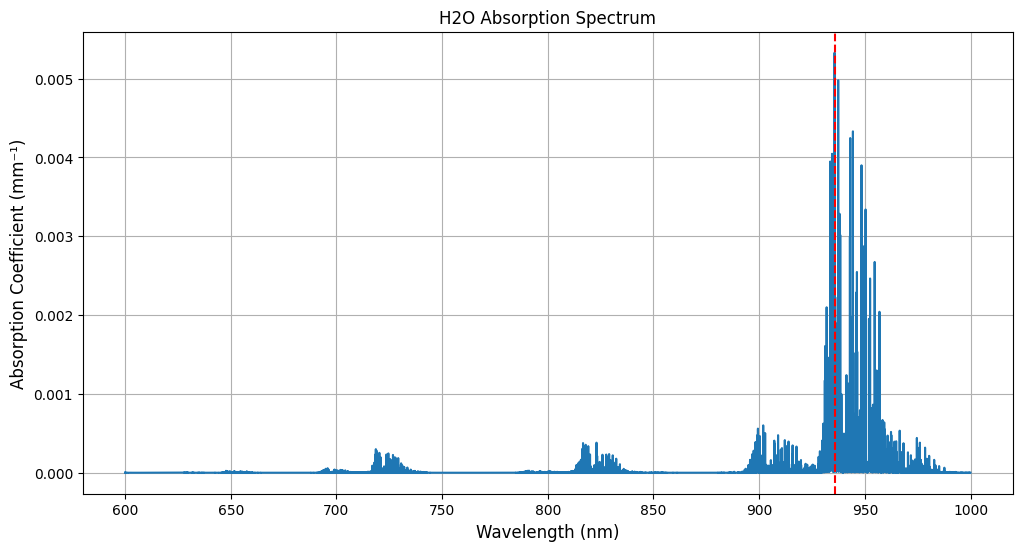

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(lambda_nm_H2O, alpha_nu_mm_H2O) # Convert mm⁻¹ to m⁻¹ for better visibility
plt.axvline(x=wavelength_at_max_h2o, color='r', linestyle='--', label='Peak Center')
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=12)
plt.title('H2O Absorption Spectrum')
plt.grid(True)
plt.tick_params(axis='both', labelsize=10)
plt.show()

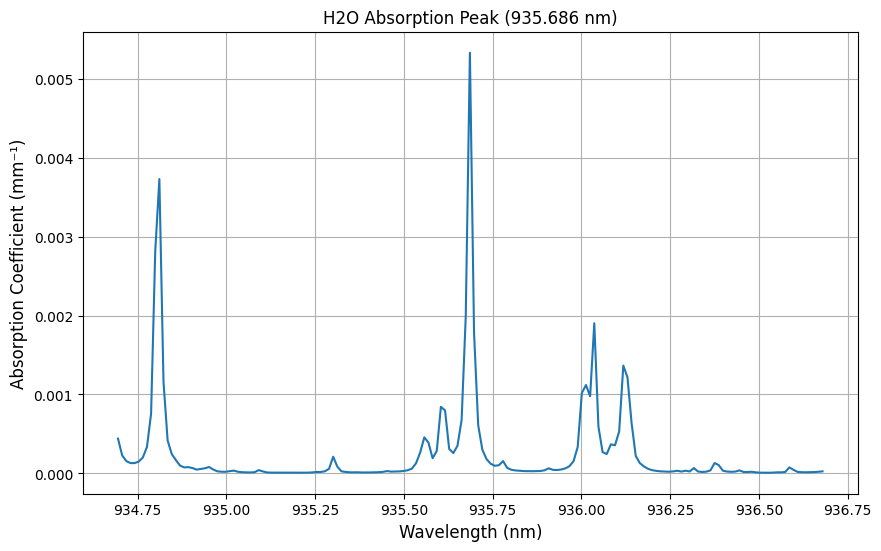

In [ ]:
peak_half_range_H2O = 1.0 # Define a range around the H2O peak for plotting

lambda_min_plot_H2O = wavelength_at_max_h2o - peak_half_range_H2O
lambda_max_plot_H2O = wavelength_at_max_h2o + peak_half_range_H2O

# Filter the data for the desired H2O peak range
mask_H2O = (lambda_nm_H2O >= lambda_min_plot_H2O) & (lambda_nm_H2O <= lambda_max_plot_H2O)
lambda_peak_H2O = lambda_nm_H2O[mask_H2O]
alpha_peak_H2O = alpha_nu_mm_H2O[mask_H2O]

plt.figure(figsize=(10, 6))
plt.plot(lambda_peak_H2O, alpha_peak_H2O ) # Convert mm⁻¹ to m⁻¹
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=12)
plt.title(f'H2O Absorption Peak ({wavelength_at_max_h2o:.3f} nm)')
plt.grid(True)
plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Remove offset from x-axis
plt.tick_params(axis='both', labelsize=10)
plt.show()

## Absorption Under Lung Conditions

To model conditions inside the lungs, we'll adjust the temperature, pressure, and mole fractions of O2 and H2O to typical physiological values.

*   **Temperature (T_GAS_LUNG):** 37°C (310.15 K)
*   **Pressure (P_ATM_LUNG):** 1.0 atm
*   **O2 Mole Fraction (X_O2_LUNG):** ~0.136 (13.6% in alveolar air)
*   **H2O Mole Fraction (X_H2O_LUNG):** ~0.062 (6.2% in saturated alveolar air at 37°C)

In [ ]:
# ── Gas conditions for O2 in Lungs ────────────────────────────────────────────
T_GAS_LUNG  = 310.15 # Temperature in Kelvin (37°C)
P_ATM_LUNG  = 1.0    # Total pressure in atm (alveolar pressure)
X_O2_LUNG   = 0.136  # Mole fraction of O2 in alveolar air

# Reuse original O2 A-band range
nu_min_O2_LUNG = 1e7 / (LAMBDA_CENTER_NM + SCAN_HALF_NM)
nu_max_O2_LUNG = 1e7 / (LAMBDA_CENTER_NM - SCAN_HALF_NM)

print(f'Wavelength range (O2 Lung) : {LAMBDA_CENTER_NM - SCAN_HALF_NM:.4f} – {LAMBDA_CENTER_NM + SCAN_HALF_NM:.4f} nm')
print(f'Wavenumber range (O2 Lung) : {nu_min_O2_LUNG:.4f} – {nu_max_O2_LUNG:.4f} cm⁻¹')

# Ensure O2 data is fetched (already done, but good practice for standalone cells)
hapi.fetch('O2_Aband', 7, 1, nu_min_O2_LUNG - 10.0, nu_max_O2_LUNG + 10.0)
print('O2 Data available ✓')
print(hapi.tableList())

# Dynamically calculate NU_STEP based on the new range and desired number of points
NU_STEP_CALC_O2_LUNG = (nu_max_O2_LUNG - nu_min_O2_LUNG) / (N_POINTS - 1)

nu_out_O2_LUNG, alpha_cm_O2_LUNG = hapi.absorptionCoefficient_Voigt(
    SourceTables  = 'O2_Aband',
    Diluent       = {'air': 1.0}, # Air as diluent for broadening (approximation for lung environment)
    Environment   = {'p': P_ATM_LUNG, 'T': T_GAS_LUNG, 'x': X_O2_LUNG}, # Specify mole fraction for O2
    HITRAN_units  = False,
    WavenumberRange = [nu_min_O2_LUNG, nu_max_O2_LUNG],
    WavenumberStep  = NU_STEP_CALC_O2_LUNG,
    WavenumberWing  = 50,
)

alpha_nu_mm_O2_LUNG = np.array(alpha_cm_O2_LUNG) * 0.1   # cm⁻¹ → mm⁻¹
nu_arr_O2_LUNG       = np.array(nu_out_O2_LUNG)
lambda_nm_O2_LUNG   = 1e7 / nu_arr_O2_LUNG
sort_idx_O2_LUNG    = np.argsort(lambda_nm_O2_LUNG)
lambda_nm_O2_LUNG   = lambda_nm_O2_LUNG[sort_idx_O2_LUNG]
alpha_nu_mm_O2_LUNG = alpha_nu_mm_O2_LUNG[sort_idx_O2_LUNG]

alpha_interp_O2_LUNG = interp1d(lambda_nm_O2_LUNG, alpha_nu_mm_O2_LUNG,
                        kind='linear', fill_value=0, bounds_error=False)

print(f'Peak absorption (O2 Lung)  : {alpha_nu_mm_O2_LUNG.max():.5f} mm⁻¹')
print(f'Peak wavelength (O2 Lung)  : {lambda_nm_O2_LUNG[np.argmax(alpha_nu_mm_O2_LUNG)]:.5f} nm')

Wavelength range (O2 Lung) : 758.8425 – 768.8425 nm
Wavenumber range (O2 Lung) : 13006.5649 – 13177.9650 cm⁻¹

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: O2_Aband
  65536 bytes written to ./hapi_data/O2_Aband.data
Header written to ./hapi_data/O2_Aband.header
END DOWNLOAD
                     Lines parsed: 133
PROCESSED
O2 Data available ✓
dict_keys(['sampletab', 'O2_Aband', 'H2O'])
{'air': 1.0}
0.278014 seconds elapsed for abscoef; nlines = 133
Peak absorption (O2 Lung)  : 0.00013 mm⁻¹
Peak wavelength (O2 Lung)  : 760.65444 nm


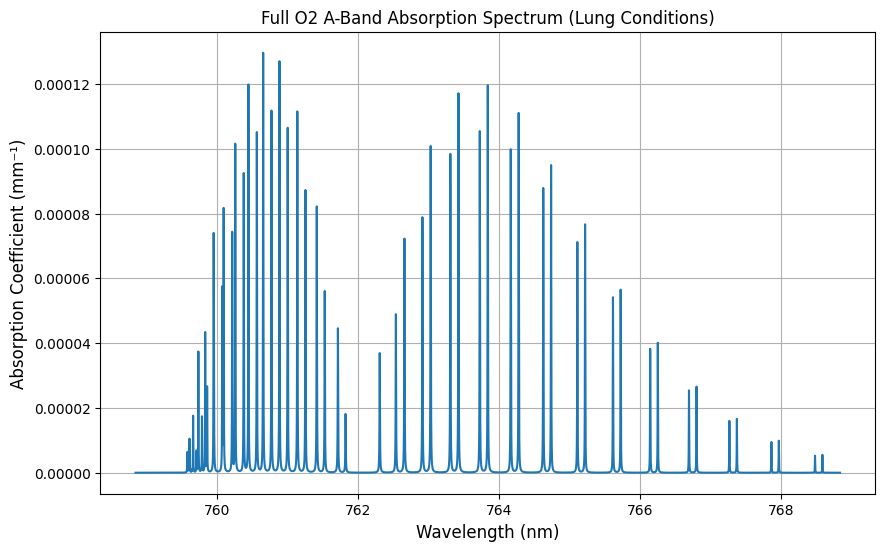

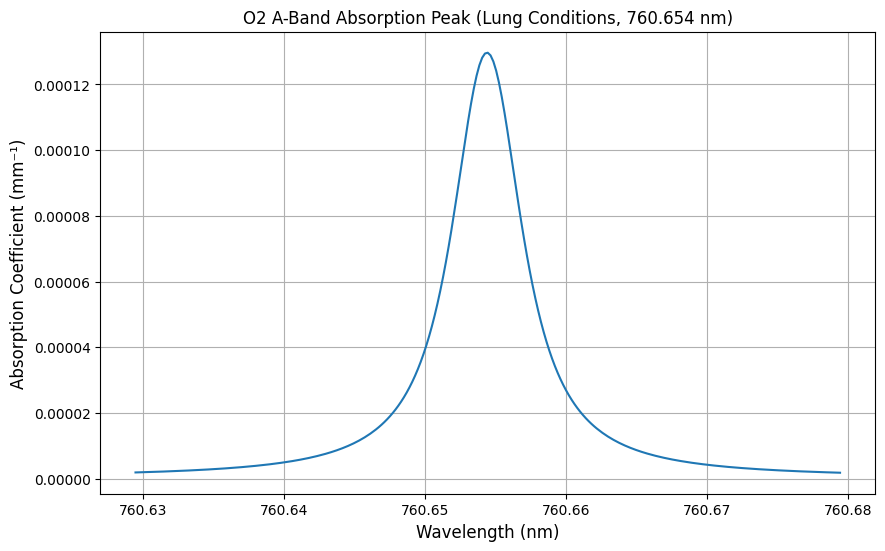

In [ ]:
# Plot full O2 A-Band Absorption Spectrum under Lung Conditions
plt.figure(figsize=(10, 6))
plt.plot(lambda_nm_O2_LUNG, alpha_nu_mm_O2_LUNG)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=12)
plt.title('Full O2 A-Band Absorption Spectrum (Lung Conditions)')
plt.grid(True)
plt.tick_params(axis='both', labelsize=10)
plt.show()

# Plot O2 A-Band peak under Lung Conditions
peak_center_O2_LUNG = lambda_nm_O2_LUNG[np.argmax(alpha_nu_mm_O2_LUNG)]
peak_half_range_O2_LUNG = 0.025 # Use same range as before for consistent visualization

lambda_min_plot_O2_LUNG = peak_center_O2_LUNG - peak_half_range_O2_LUNG
lambda_max_plot_O2_LUNG = peak_center_O2_LUNG + peak_half_range_O2_LUNG

mask_O2_LUNG = (lambda_nm_O2_LUNG >= lambda_min_plot_O2_LUNG) & (lambda_nm_O2_LUNG <= lambda_max_plot_O2_LUNG)
lambda_peak_O2_LUNG = lambda_nm_O2_LUNG[mask_O2_LUNG]
alpha_peak_O2_LUNG = alpha_nu_mm_O2_LUNG[mask_O2_LUNG]

plt.figure(figsize=(10, 6))
plt.plot(lambda_peak_O2_LUNG, alpha_peak_O2_LUNG)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=12)
plt.title(f'O2 A-Band Absorption Peak (Lung Conditions, {peak_center_O2_LUNG:.3f} nm)')
plt.grid(True)
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.tick_params(axis='both', labelsize=10)
plt.show()

In [ ]:
# ── Gas conditions for H2O in Lungs ────────────────────────────────────────────
# T_GAS_LUNG and P_ATM_LUNG are already defined
import math

# Calculate saturation vapor pressure at 37°C (310.15 K)
# Using Tetens' formula (simplified) for P_sat in kPa (T in Celsius)
T_CELSIUS = T_GAS_LUNG - 273.15  # Convert Kelvin to Celsius
P_SAT_KPA = 0.61078 * math.exp((17.27 * T_CELSIUS) / (T_CELSIUS + 237.3))

# Convert P_sat to atm
P_SAT_ATM = P_SAT_KPA / 101.325 # 1 atm = 101.325 kPa

# Given Relative Humidity (RH)
RH = 0.995 # 99.5%

# Calculate partial pressure of water vapor
P_H2O_PARTIAL = RH * P_SAT_ATM

# Calculate mole fraction of water vapor (X_H2O) using Dalton's law: X_H2O = P_H2O_partial / P_total
X_H2O_LUNG  = P_H2O_PARTIAL / P_ATM_LUNG  # Mole fraction of water vapor in alveolar air

print(f'Calculated X_H2O_LUNG based on 99.5% RH at 37°C: {X_H2O_LUNG:.5f}')

# Reuse H2O-specific spectral range
nu_min_H2O_LUNG = 1e7 / lambda_max_nm_H2O
nu_max_H2O_LUNG = 1e7 / lambda_min_nm_H2O

print(f'Wavelength range (H2O Lung) : {lambda_min_nm_H2O:.4f} – {lambda_max_nm_H2O:.4f} nm')
print(f'Wavenumber range (H2O Lung) : {nu_min_H2O_LUNG:.4f} – {nu_max_H2O_LUNG:.4f} cm⁻¹')

# Ensure H2O data is fetched (already done, but good practice for standalone cells)
hapi.fetch('H2O', 1, 1, nu_min_H2O_LUNG - 50.0, nu_max_H2O_LUNG + 50.0)
print('H2O Data available ✓')

# Dynamically calculate NU_STEP for the H2O range
NU_STEP_CALC_H2O_LUNG = (nu_max_H2O_LUNG - nu_min_H2O_LUNG) / (N_POINTS - 1)

# Calculate absorption coefficient for H2O using the Voigt profile
nu_out_H2O_LUNG, alpha_cm_H2O_LUNG = hapi.absorptionCoefficient_Voigt(
    SourceTables  = 'H2O',
    Diluent       = {'air': 1.0},
    Environment   = {'p': P_ATM_LUNG, 'T': T_GAS_LUNG, 'x': X_H2O_LUNG}, # Specify mole fraction for H2O
    HITRAN_units  = False,
    WavenumberRange = [nu_min_H2O_LUNG, nu_max_H2O_LUNG],
    WavenumberStep  = NU_STEP_CALC_H2O_LUNG,
    WavenumberWing  = 100,
)

alpha_nu_mm_H2O_LUNG = np.array(alpha_cm_H2O_LUNG) * 0.1   # cm⁻¹ → mm⁻¹
nu_arr_H2O_LUNG       = np.array(nu_out_H2O_LUNG)
lambda_nm_H2O_LUNG   = 1e7 / nu_arr_H2O_LUNG
sort_idx_H2O_LUNG    = np.argsort(lambda_nm_H2O_LUNG)
lambda_nm_H2O_LUNG   = lambda_nm_H2O_LUNG[sort_idx_H2O_LUNG]
alpha_nu_mm_H2O_LUNG = alpha_nu_mm_H2O_LUNG[sort_idx_H2O_LUNG]

alpha_interp_H2O_LUNG = interp1d(lambda_nm_H2O_LUNG, alpha_nu_mm_H2O_LUNG,
                        kind='linear', fill_value=0, bounds_error=False)

print(f'Peak absorption (H2O Lung) : {alpha_nu_mm_H2O_LUNG.max():.5f} mm⁻¹')
print(f'Peak wavelength (H2O Lung) : {lambda_nm_H2O_LUNG[np.argmax(alpha_nu_mm_H2O_LUNG)]:.5f} nm')

Calculated X_H2O_LUNG based on 99.5% RH at 37°C: 0.06162
Wavelength range (H2O Lung) : 600.0000 – 1000.0000 nm
Wavenumber range (H2O Lung) : 10000.0000 – 16666.6667 cm⁻¹

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_data/H2O.data
  65536 bytes written to ./hapi_d

/usr/local/lib/python3.12/dist-packages/hapi/hapi.py:53595: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


{'air': 1.0}
74.790103 seconds elapsed for abscoef; nlines = 85736
Peak absorption (H2O Lung) : 0.00505 mm⁻¹
Peak wavelength (H2O Lung) : 935.68590 nm


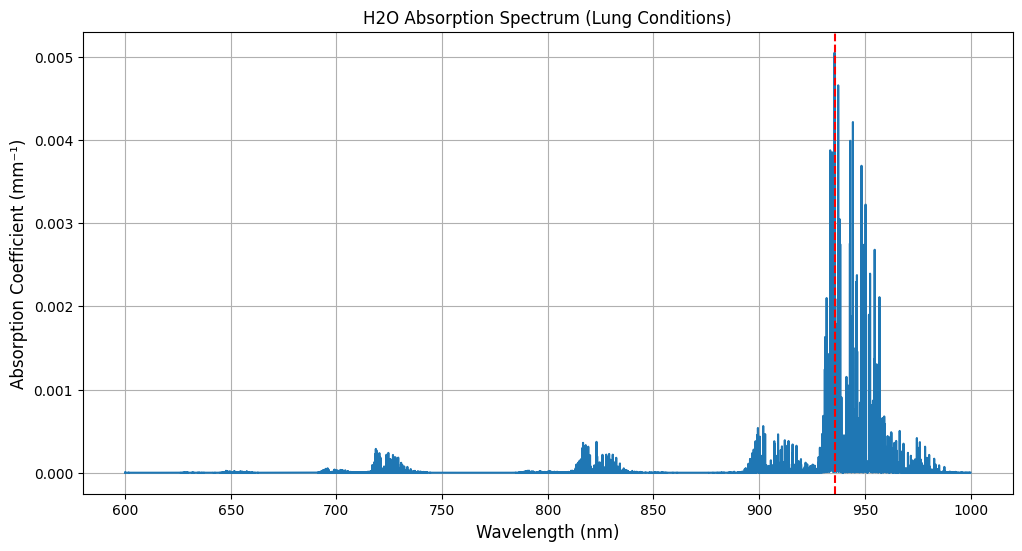

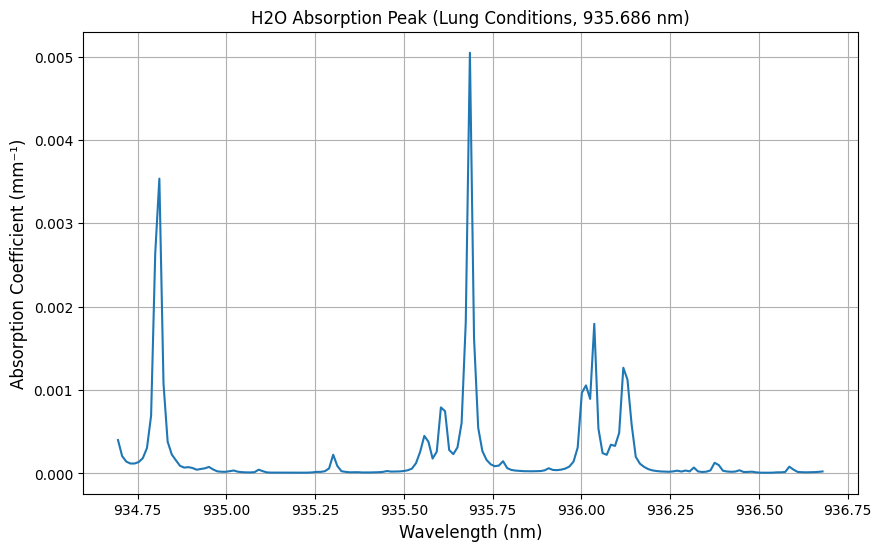

In [ ]:
# Plot full H2O Absorption Spectrum under Lung Conditions
plt.figure(figsize=(12, 6))
plt.plot(lambda_nm_H2O_LUNG, alpha_nu_mm_H2O_LUNG)
max_absorption_h2o_lung = alpha_nu_mm_H2O_LUNG.max()
wavelength_at_max_h2o_lung = lambda_nm_H2O_LUNG[np.argmax(alpha_nu_mm_H2O_LUNG)]
plt.axvline(x=wavelength_at_max_h2o_lung, color='r', linestyle='--', label='Peak Center')
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=12)
plt.title('H2O Absorption Spectrum (Lung Conditions)')
plt.grid(True)
plt.tick_params(axis='both', labelsize=10)
plt.show()

# Plot H2O peak under Lung Conditions
peak_half_range_H2O_LUNG = 1.0 # Define a range around the H2O peak for plotting

lambda_min_plot_H2O_LUNG = wavelength_at_max_h2o_lung - peak_half_range_H2O_LUNG
lambda_max_plot_H2O_LUNG = wavelength_at_max_h2o_lung + peak_half_range_H2O_LUNG

mask_H2O_LUNG = (lambda_nm_H2O_LUNG >= lambda_min_plot_H2O_LUNG) & (lambda_nm_H2O_LUNG <= lambda_max_plot_H2O_LUNG)
lambda_peak_H2O_LUNG = lambda_nm_H2O_LUNG[mask_H2O_LUNG]
alpha_peak_H2O_LUNG = alpha_nu_mm_H2O_LUNG[mask_H2O_LUNG]

plt.figure(figsize=(10, 6))
plt.plot(lambda_peak_H2O_LUNG, alpha_peak_H2O_LUNG)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorption Coefficient (mm⁻¹)', fontsize=12)
plt.title(f'H2O Absorption Peak (Lung Conditions, {wavelength_at_max_h2o_lung:.3f} nm)')
plt.grid(True)
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.tick_params(axis='both', labelsize=10)
plt.show()